In [1]:
# Email Spam Detection using NLP
# ==========================================

# Import Libraries
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download Required NLTK Files
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# ==========================================
# Step 1 : Collect Email Dataset
# ==========================================

data = {
    "Email": [
        "Congratulations! You won a free iPhone. Click here now.",
        "Meeting has been scheduled at 10 AM tomorrow.",
        "Limited time offer. Buy one get one free.",
        "Please submit your project report today.",
        "Win cash prizes by clicking this link.",
        "Team meeting postponed to Monday.",
        "Exclusive discount available only today.",
        "Can you send me the assignment?",
        "Claim your lottery prize now.",
        "Project discussion at 2 PM."
    ],

    "Label": [
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham",
        "Spam",
        "Ham"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("Email Dataset")
print(df)


Email Dataset
                                               Email Label
0  Congratulations! You won a free iPhone. Click ...  Spam
1      Meeting has been scheduled at 10 AM tomorrow.   Ham
2          Limited time offer. Buy one get one free.  Spam
3           Please submit your project report today.   Ham
4             Win cash prizes by clicking this link.  Spam
5                  Team meeting postponed to Monday.   Ham
6           Exclusive discount available only today.  Spam
7                    Can you send me the assignment?   Ham
8                      Claim your lottery prize now.  Spam
9                        Project discussion at 2 PM.   Ham


In [3]:
# ==========================================
# Step 2 : Preprocess Email Text
# ==========================================

stop_words = set(stopwords.words('english'))

def Clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words
    cleaned_text = " ".join(words)

    return cleaned_text

# Apply Cleaning
df["Cleaned_Email"] = df["Email"].apply(Clean_text)

print("\nCleaned Emails\n")
print(df["Cleaned_Email"])


Cleaned Emails

0          congratulations free iphone click
1                 meeting scheduled tomorrow
2    limited time offer buy one get one free
3         please submit project report today
4              win cash prizes clicking link
5              team meeting postponed monday
6         exclusive discount available today
7                            send assignment
8                        claim lottery prize
9                      project discussion pm
Name: Cleaned_Email, dtype: object


In [4]:
# ==========================================
# Step 3 : Build Spam Classification Model
# ==========================================

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["Cleaned_Email"])

y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

model = MultinomialNB()

model.fit(X_train, y_train)

prediction = model.predict(X_test)

print("\nPredicted Labels")
print(prediction)


Predicted Labels
['Ham' 'Ham' 'Ham']


In [5]:
# ==========================================
# Step 4 : Evaluate Classification Accuracy
# ==========================================

accuracy = accuracy_score(y_test, prediction)

print("\nClassification Accuracy")
print(accuracy)

print("\nClassification Report")
print(classification_report(y_test, prediction))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, prediction))


Classification Accuracy
0.6666666666666666

Classification Report
              precision    recall  f1-score   support

         Ham       0.67      1.00      0.80         2
        Spam       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3


Confusion Matrix
[[2 0]
 [1 0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


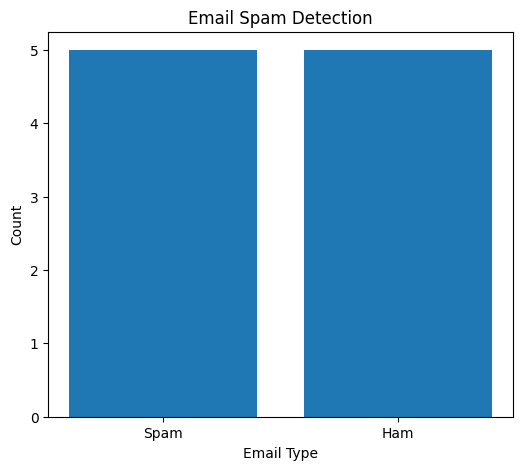

In [6]:
# ==========================================
# Step 5 : Generate Spam Analysis Report
# ==========================================

spam_count = len(df[df["Label"]=="Spam"])
ham_count = len(df[df["Label"]=="Ham"])

plt.figure(figsize=(6,5))
plt.bar(["Spam","Ham"],[spam_count,ham_count])

plt.title("Email Spam Detection")
plt.xlabel("Email Type")
plt.ylabel("Count")

plt.show()

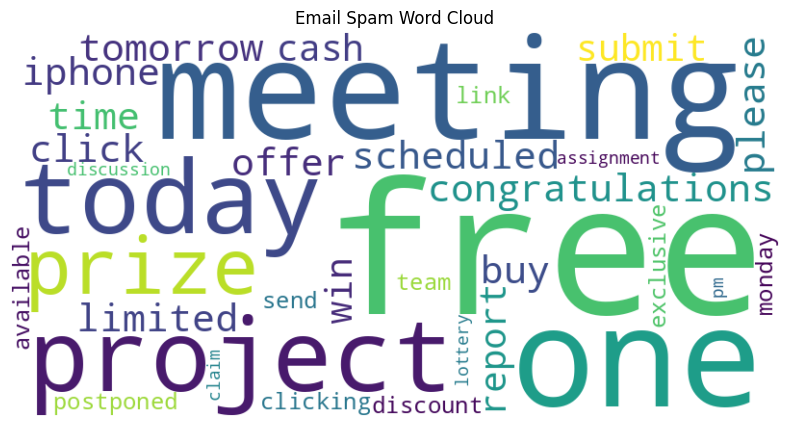

In [9]:
# ==========================================
# Word Cloud
# ==========================================

from wordcloud import WordCloud

# Combine all cleaned emails
all_words = " ".join(df["Cleaned_Email"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Email Spam Word Cloud")
plt.show()

In [7]:
print("\nSpam Analysis Report")
print("--------------------------------")

print("Total Emails :",len(df))
print("Spam Emails :",spam_count)
print("Non-Spam Emails :",ham_count)

print("\nModel Accuracy :",round(accuracy*100,2),"%")

print("\nRecommendations")
print("1. Block suspicious senders.")
print("2. Avoid clicking unknown links.")
print("3. Enable spam filters.")
print("4. Update email security regularly.")
print("5. Verify unknown attachments before opening.")


Spam Analysis Report
--------------------------------
Total Emails : 10
Spam Emails : 5
Non-Spam Emails : 5

Model Accuracy : 66.67 %

Recommendations
1. Block suspicious senders.
2. Avoid clicking unknown links.
3. Enable spam filters.
4. Update email security regularly.
5. Verify unknown attachments before opening.
